# Analyse Exploratoire des Données (EDA)
Exploration des cycles temporels, de l'impact météorologique et des effets calendaires.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

MOIS = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
JOURS_SEMAINE = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']

In [3]:
df = pd.read_csv('../data/processed/dataset_final.csv')
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
df['timestamp_paris'] = pd.to_datetime(df['timestamp_paris'], utc=True).dt.tz_convert('Europe/Paris')
df.head()

,timestamp_utc,timestamp_paris,consommation_mw,source_donnee,heure,jour_semaine,jour_annee,mois,annee,saison,...,temperature_c_pondere_pop,temperature_point_rosee_c_pondere_pop,humidite_pct_pondere_pop,vent_direction_deg_pondere_pop,vent_vitesse_ms_pondere_pop,nebulosite_pondere_pop,precip_1h_mm_pondere_pop,weekend,ferie,vacances
0,2016-01-01 00:00:00+00:00,2016-01-01 01:00:00+01:00,56569.0,Données définitives,1,4,1,1,2016,Hiver,...,7.161313,6.036176,92.69971,141.342131,1.398133,87.926456,0.0,False,True,3
1,2016-01-01 01:00:00+00:00,2016-01-01 02:00:00+01:00,55506.5,Données définitives,2,4,1,1,2016,Hiver,...,7.161313,6.036176,92.69971,141.342131,1.398133,87.926456,0.0,False,True,3
2,2016-01-01 02:00:00+00:00,2016-01-01 03:00:00+01:00,52404.0,Données définitives,3,4,1,1,2016,Hiver,...,7.161313,6.036176,92.69971,141.342131,1.398133,87.926456,0.0,False,True,3
3,2016-01-01 03:00:00+00:00,2016-01-01 04:00:00+01:00,49776.0,Données définitives,4,4,1,1,2016,Hiver,...,5.531252,4.881011,95.60412,152.449308,0.894432,86.546508,0.0,False,True,3
4,2016-01-01 04:00:00+00:00,2016-01-01 05:00:00+01:00,48761.0,Données définitives,5,4,1,1,2016,Hiver,...,5.531252,4.881011,95.60412,152.449308,0.894432,85.108657,0.0,False,True,3


In [4]:
df.tail()

,timestamp_utc,timestamp_paris,consommation_mw,source_donnee,heure,jour_semaine,jour_annee,mois,annee,saison,...,temperature_c_pondere_pop,temperature_point_rosee_c_pondere_pop,humidite_pct_pondere_pop,vent_direction_deg_pondere_pop,vent_vitesse_ms_pondere_pop,nebulosite_pondere_pop,precip_1h_mm_pondere_pop,weekend,ferie,vacances
94219,2026-09-30 19:00:00+00:00,2026-09-30 21:00:00+02:00,44329.75,Données temps réel,21,2,273,9,2026,Automne,...,20.922769,16.503912,77.848716,193.215159,3.695477,97.594697,0.337787,False,False,0
94220,2026-09-30 20:00:00+00:00,2026-09-30 22:00:00+02:00,43508.75,Données temps réel,22,2,273,9,2026,Automne,...,20.922769,16.503912,77.848716,193.215159,3.695477,97.594697,0.337787,False,False,0
94221,2026-09-30 21:00:00+00:00,2026-09-30 23:00:00+02:00,42950.00,Données temps réel,23,2,273,9,2026,Automne,...,19.077903,16.507243,85.892421,174.138142,3.193888,98.059291,0.573203,False,False,0
94222,2026-09-30 22:00:00+00:00,2026-10-01 00:00:00+02:00,41006.75,Données temps réel,0,3,274,10,2026,Automne,...,19.077903,16.507243,85.892421,174.138142,3.193888,98.556132,0.573203,False,False,0
94223,2026-09-30 23:00:00+00:00,2026-10-01 01:00:00+02:00,38884.75,Données temps réel,1,3,274,10,2026,Automne,...,19.077903,16.507243,85.892421,174.138142,3.193888,98.556132,0.573203,False,False,0


## 0. Analyse Descriptive

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94224 entries, 0 to 94223
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype                       
---  ------                                 --------------  -----                       
 0   timestamp_utc                          94224 non-null  datetime64[us, UTC]         
 1   timestamp_paris                        94224 non-null  datetime64[us, Europe/Paris]
 2   consommation_mw                        94224 non-null  float64                     
 3   source_donnee                          94224 non-null  str                         
 4   heure                                  94224 non-null  int64                       
 5   jour_semaine                           94224 non-null  int64                       
 6   jour_annee                             94224 non-null  int64                       
 7   mois                                   94224 non-null  int64                       
 8   annee  

In [6]:
df.describe()

,consommation_mw,heure,jour_semaine,jour_annee,mois,annee,confinement_numero,temperature_c,temperature_point_rosee_c,humidite_pct,...,nebulosite,precip_1h_mm,temperature_c_pondere_pop,temperature_point_rosee_c_pondere_pop,humidite_pct_pondere_pop,vent_direction_deg_pondere_pop,vent_vitesse_ms_pondere_pop,nebulosite_pondere_pop,precip_1h_mm_pondere_pop,vacances
count,94224.000000,94224.000000,94224.000000,94224.000000,94224.000000,94224.000000,3215.000000,94224.000000,94224.000000,94224.000000,...,94224.000000,94224.000000,94224.000000,94224.000000,94224.000000,94224.000000,94224.000000,94224.000000,94224.000000,94224.000000
mean,52158.201138,11.499989,2.999958,179.968766,6.418641,2020.882174,1.813686,13.734802,8.669386,74.618475,...,81.119994,0.073208,13.586785,8.362904,73.986909,194.163898,3.246842,76.908682,0.074187,1.034927
std,11400.166005,6.922239,2.000239,104.485856,3.417064,3.104189,0.783979,7.088583,5.003601,14.592056,...,22.287153,0.173854,7.245098,5.055810,15.339852,54.175310,1.446047,24.641198,0.193616,1.317078
min,29364.500000,0.000000,0.000000,1.000000,1.000000,2016.000000,1.000000,-6.625000,-12.630769,23.384615,...,0.000000,0.000000,-6.686636,-14.014853,19.972188,33.215159,0.235636,0.000000,0.000000,0.000000
25%,43609.375000,5.750000,1.000000,90.000000,3.000000,2018.000000,1.000000,8.392308,4.984615,65.076923,...,76.250000,0.000000,8.160116,4.676650,64.003973,154.410147,2.176345,67.970220,0.000000,0.000000
50%,50312.000000,11.500000,3.000000,179.000000,6.000000,2021.000000,2.000000,13.169231,8.838462,78.230769,...,89.100000,0.000000,13.021974,8.540587,77.704156,194.187940,3.041259,85.848019,0.000000,0.000000
75%,59694.125000,17.250000,5.000000,268.000000,9.000000,2024.000000,2.000000,18.769231,12.815385,86.307692,...,95.500000,0.061538,18.710177,12.536094,86.258252,234.077017,4.105287,94.917283,0.056082,3.000000
max,96129.500000,23.000000,6.000000,366.000000,12.000000,2026.000000,3.000000,37.684615,20.853846,98.461538,...,101.000000,4.730769,38.151345,20.666870,98.804401,340.849633,11.461247,101.000000,7.612317,3.000000


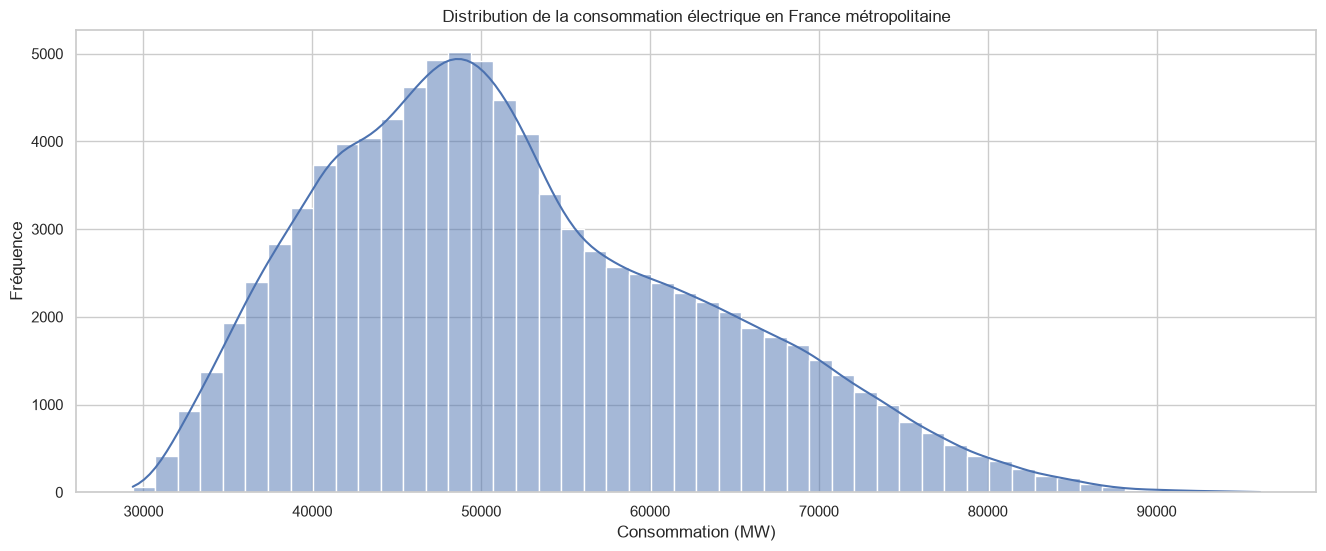

In [7]:
plt.figure(figsize=(16, 6))
sns.histplot(
    df["consommation_mw"],
    bins=50,
	kde=True,
)

plt.title("Distribution de la consommation électrique en France métropolitaine")
plt.xlabel("Consommation (MW)")
plt.ylabel("Fréquence")
plt.show()

In [8]:
valeurs_manquantes = df.isna().sum()
valeurs_manquantes = valeurs_manquantes[valeurs_manquantes > 0]

print("Nombre de valeurs manquantes par colonne :")
print(valeurs_manquantes)

nombre_doublons = df["timestamp_paris"].duplicated().sum()
print(f"\nNombre de timestamps en doublon : {nombre_doublons}")

ecart = df["timestamp_paris"].diff()
print("\nIntervalles :")
print(ecart.value_counts())

Nombre de valeurs manquantes par colonne :
confinement_numero    91009
dtype: int64

Nombre de timestamps en doublon : 0

Intervalles :
timestamp_paris
0 days 01:00:00    94223
Name: count, dtype: int64


In [9]:
print("Consommation minimale :")
print(df.loc[df["consommation_mw"].idxmin()])

print("\nConsommation maximale :")
print(df.loc[df["consommation_mw"].idxmax()])

Consommation minimale :
timestamp_utc                            2020-05-10 05:00:00+00:00
timestamp_paris                          2020-05-10 07:00:00+02:00
consommation_mw                                            29364.5
source_donnee                                  Données définitives
heure                                                            7
jour_semaine                                                     6
jour_annee                                                     131
mois                                                             5
annee                                                         2020
saison                                                   Printemps
confinement_numero                                             1.0
temperature_c                                            15.161538
temperature_point_rosee_c                                13.323077
humidite_pct                                             89.153846
vent_direction_deg                    

## 1. Analyse Séries Temporelles

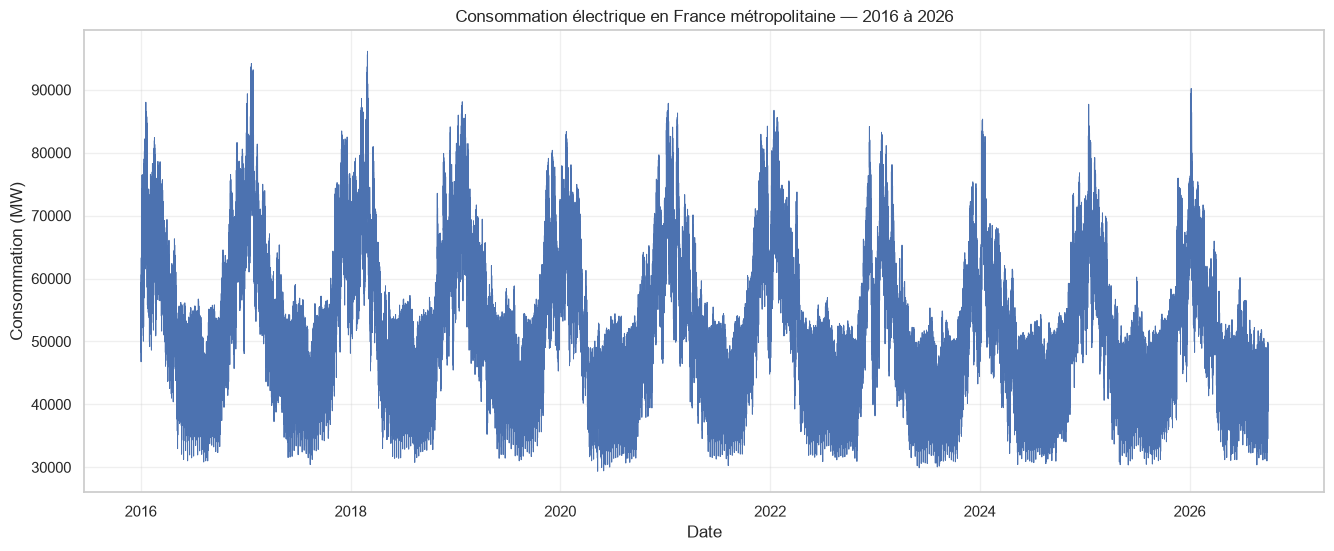

In [10]:
plt.figure(figsize=(16, 6))
plt.plot(
    df["timestamp_paris"],
    df["consommation_mw"],
    linewidth=0.7
)

plt.title("Consommation électrique en France métropolitaine — 2016 à 2026")
plt.xlabel("Date")
plt.ylabel("Consommation (MW)")
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
print("Frequence de l'echantillonnage :")
df["timestamp_paris"].diff().value_counts()

Frequence de l'echantillonnage :


timestamp_paris
0 days 01:00:00    94223
Name: count, dtype: int64

### 1.1 Cycle Annuel

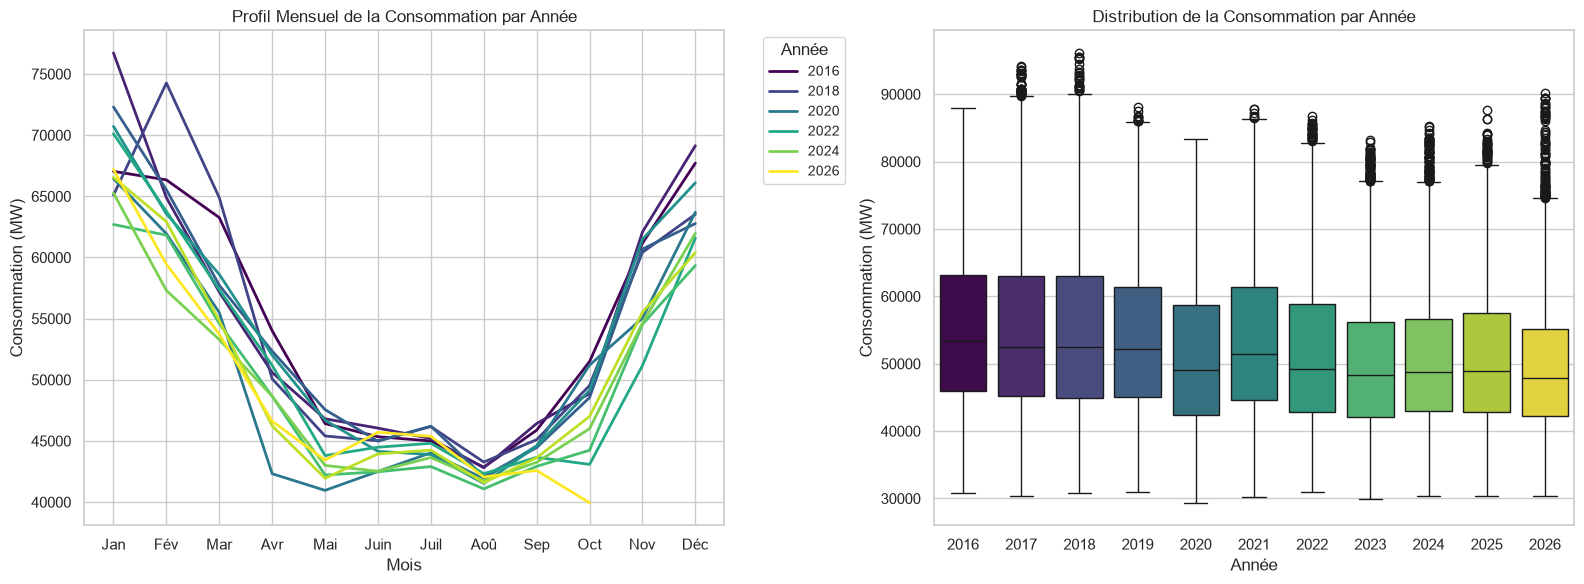

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(data=df, x='mois', y='consommation_mw', hue='annee', ax=axes[0], palette="viridis", errorbar=None, linewidth=2)
axes[0].set_title("Profil Mensuel de la Consommation par Année")
axes[0].set_xlabel("Mois")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(MOIS)
axes[0].set_ylabel("Consommation (MW)")
axes[0].legend(title="Année", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

sns.boxplot(data=df, x='annee', y='consommation_mw', ax=axes[1], hue='annee', palette="viridis", legend=False)
axes[1].set_title("Distribution de la Consommation par Année")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()


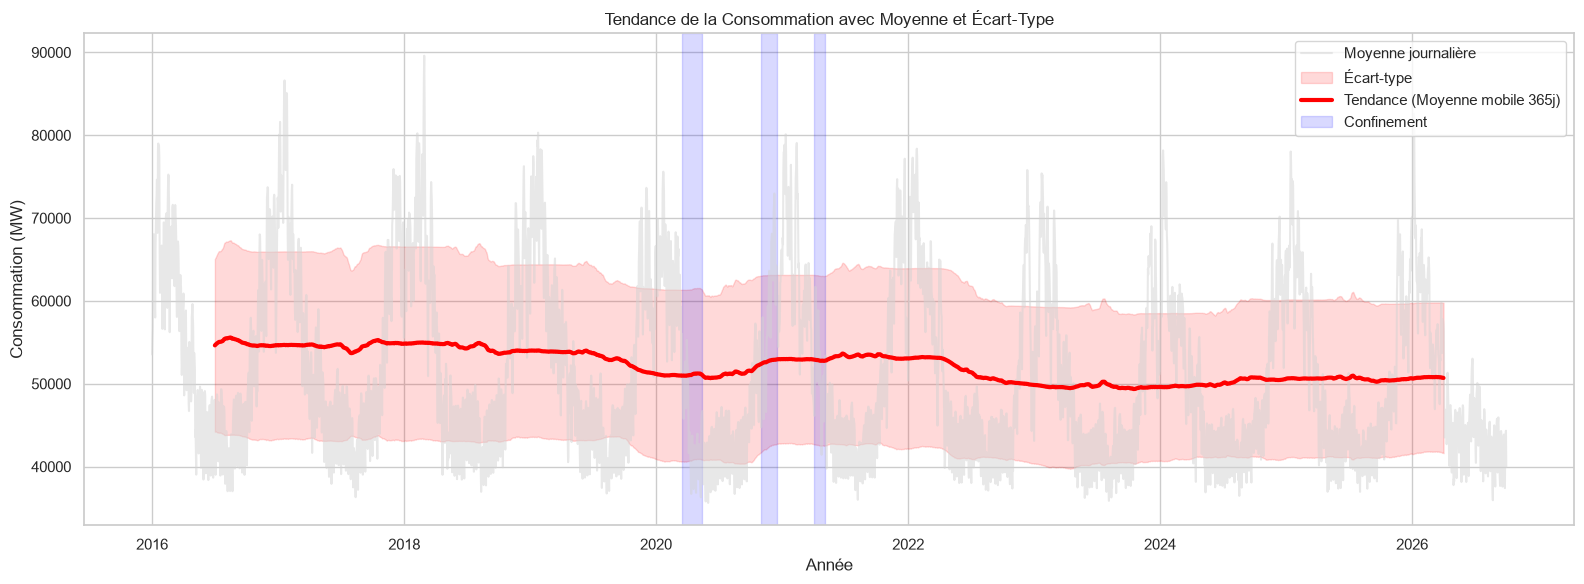

In [13]:
plt.figure(figsize=(16, 6))

df_daily = df.groupby(df['timestamp_paris'].dt.date)['consommation_mw'].mean().reset_index()

df_daily['moyenne_mobile_365j'] = df_daily['consommation_mw'].rolling(window=365, center=True).mean()
df_daily['ecart_type_365j'] = df_daily['consommation_mw'].rolling(window=365, center=True).std()
df_daily['bande_haute'] = df_daily['moyenne_mobile_365j'] + df_daily['ecart_type_365j']
df_daily['bande_basse'] = df_daily['moyenne_mobile_365j'] - df_daily['ecart_type_365j']

sns.lineplot(data=df_daily, x='timestamp_paris', y='consommation_mw', color="lightgray", label="Moyenne journalière", alpha=0.5)

plt.fill_between(
	df_daily['timestamp_paris'], df_daily['bande_basse'], df_daily['bande_haute'], color="red", alpha=0.15, label="Écart-type"
)
sns.lineplot(
	data=df_daily, x='timestamp_paris', y='moyenne_mobile_365j', color="red", linewidth=3, label="Tendance (Moyenne mobile 365j)"
)

periodes_confinement = (
    df[df["confinement_numero"] > 0]
    .groupby("confinement_numero")["timestamp_paris"]
    .agg(["min", "max"])
)

for confinement, periode in periodes_confinement.iterrows():
    debut = periode["min"].tz_localize(None)
    fin = periode["max"].tz_localize(None)

    plt.axvspan(debut, fin, color="blue", alpha=0.15, label=f"Confinement" if confinement == 1 else None)

plt.title("Tendance de la Consommation avec Moyenne et Écart-Type")
plt.xlabel("Année")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.tight_layout()
plt.show()

Ici, on peut voir aussi l'éffet des confinements sur la consommation moyenne, notament la premier confinement.

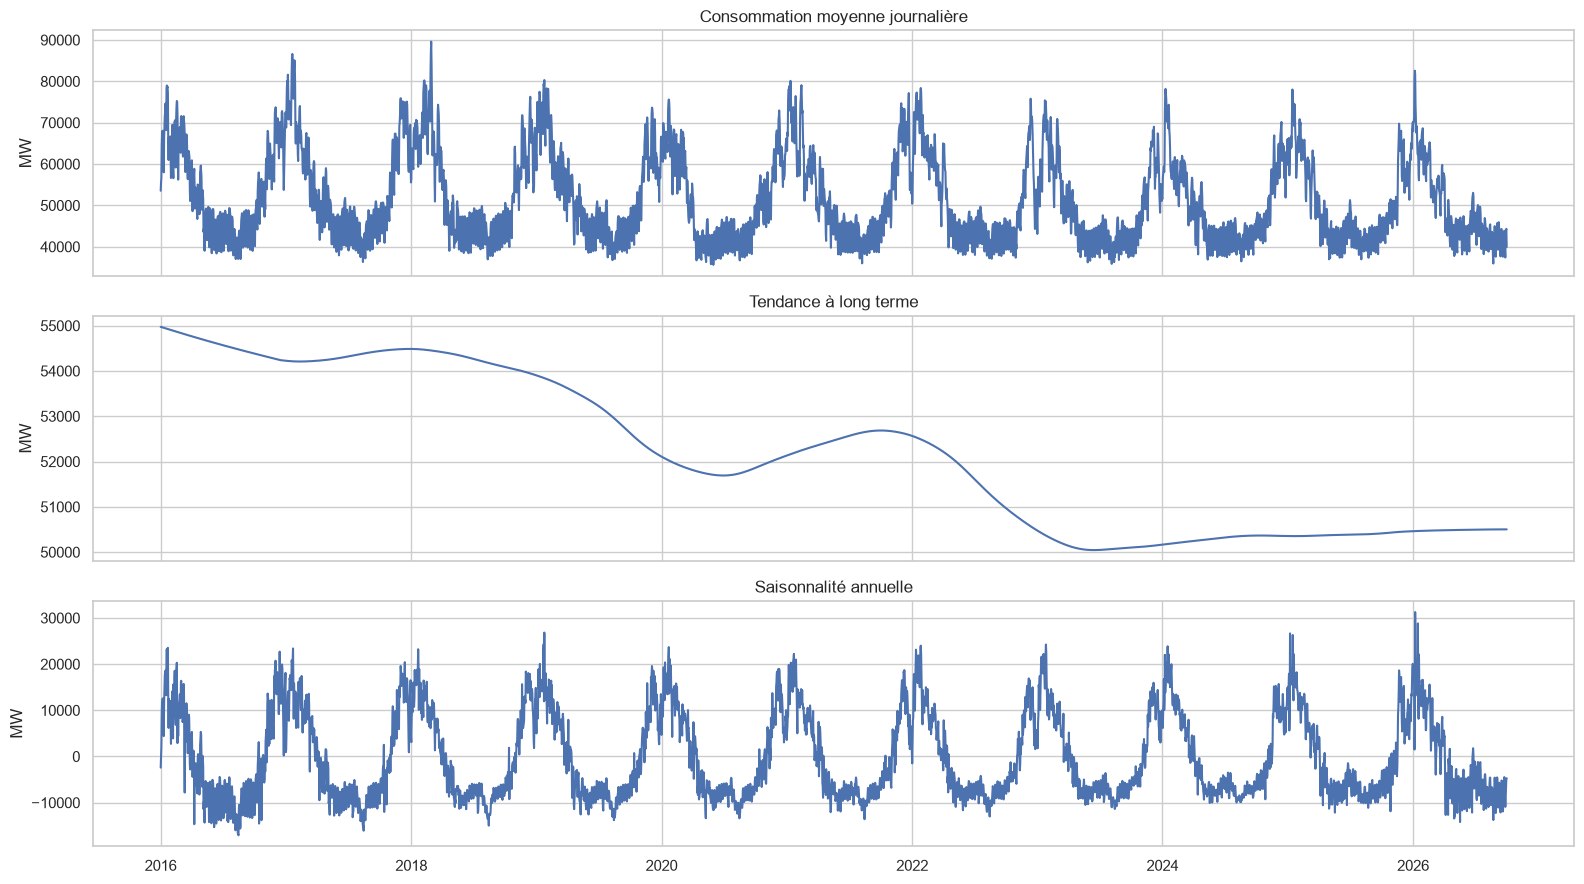

In [14]:
daily = df.set_index("timestamp_paris")["consommation_mw"].resample("D").mean()

stl = STL(daily, period=365, robust=True)

result = stl.fit()

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

axes[0].plot(daily)
axes[0].set_title("Consommation moyenne journalière")
axes[0].set_ylabel("MW")

axes[1].plot(result.trend)
axes[1].set_title("Tendance à long terme")
axes[1].set_ylabel("MW")

axes[2].plot(result.seasonal)
axes[2].set_title("Saisonnalité annuelle")
axes[2].set_ylabel("MW")

plt.tight_layout()
plt.show()

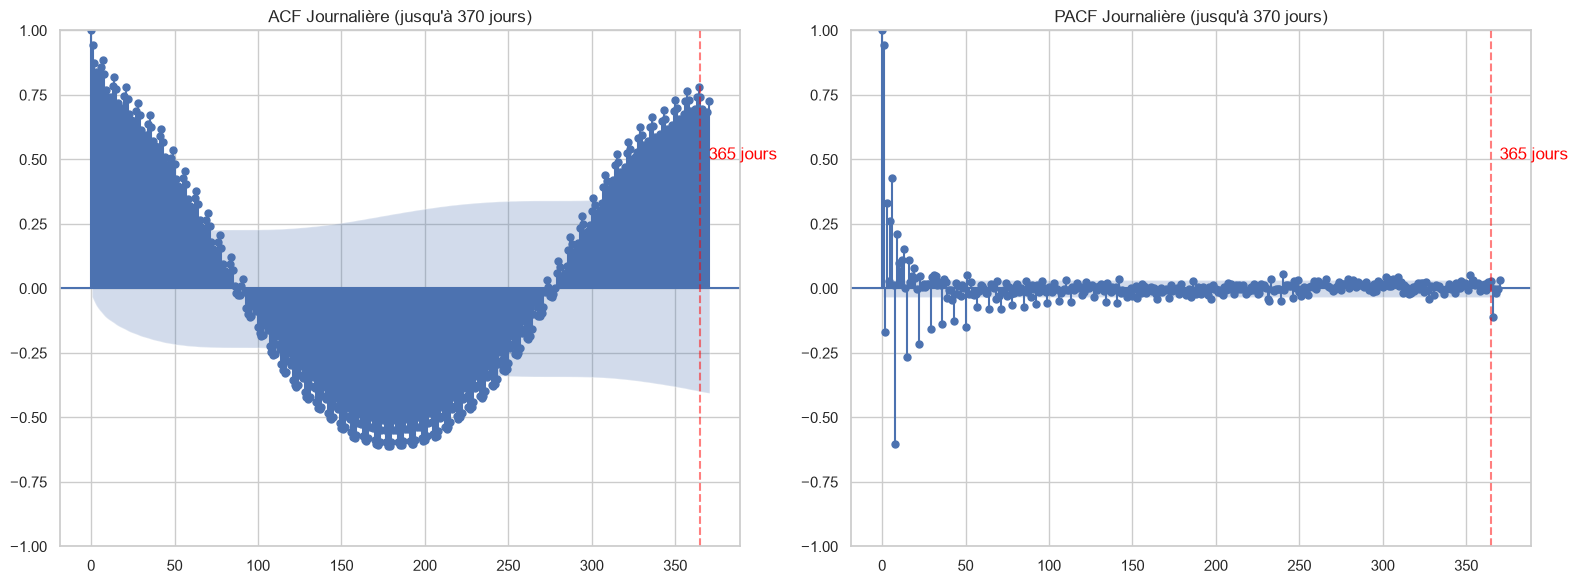

In [15]:
df_daily = df.groupby(df['timestamp_paris'].dt.date)['consommation_mw'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_acf(df_daily['consommation_mw'], lags=370, ax=axes[0], title="ACF Journalière (jusqu'à 370 jours)")
plot_pacf(df_daily['consommation_mw'], lags=370, ax=axes[1], title="PACF Journalière (jusqu'à 370 jours)")

axes[0].axvline(x=365, color='red', linestyle='--', alpha=0.5)
axes[0].text(370, 0.5, '365 jours', color='red')

axes[1].axvline(x=365, color='red', linestyle='--', alpha=0.5)
axes[1].text(370, 0.5, '365 jours', color='red')

plt.tight_layout()
plt.show()

Inter-annuel :
- Il y a pas de saisonalité ou cycle.
- Il y a une tendence confirmé par le STL et le MA : Moyenne et écart avant Covid != pendant Covid != après Covid. Après une baisse progressive avant 2020, la période COVID-19 introduit une rupture importante, suivie d'une stabilisation à un niveau globalement inférieur après 2022 et un écart stable.

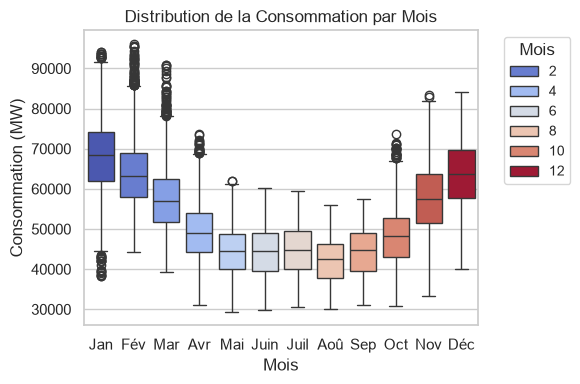

In [16]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))

sns.boxplot(data=df, x='mois', y='consommation_mw', ax=axes, hue='mois', palette="coolwarm")
axes.set_title("Distribution de la Consommation par Mois")
axes.set_xlabel("Mois")
axes.set_xticks(range(12))
axes.set_xticklabels(MOIS)
axes.set_ylabel("Consommation (MW)")
axes.legend(title="Mois", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

Annuelle :
- Il y a une saisonalité, une grande persistence ce qui est inversée au-milieu de l'année.
- Il y a pas de tendance ou cycle.

### Cycle Saisonnier

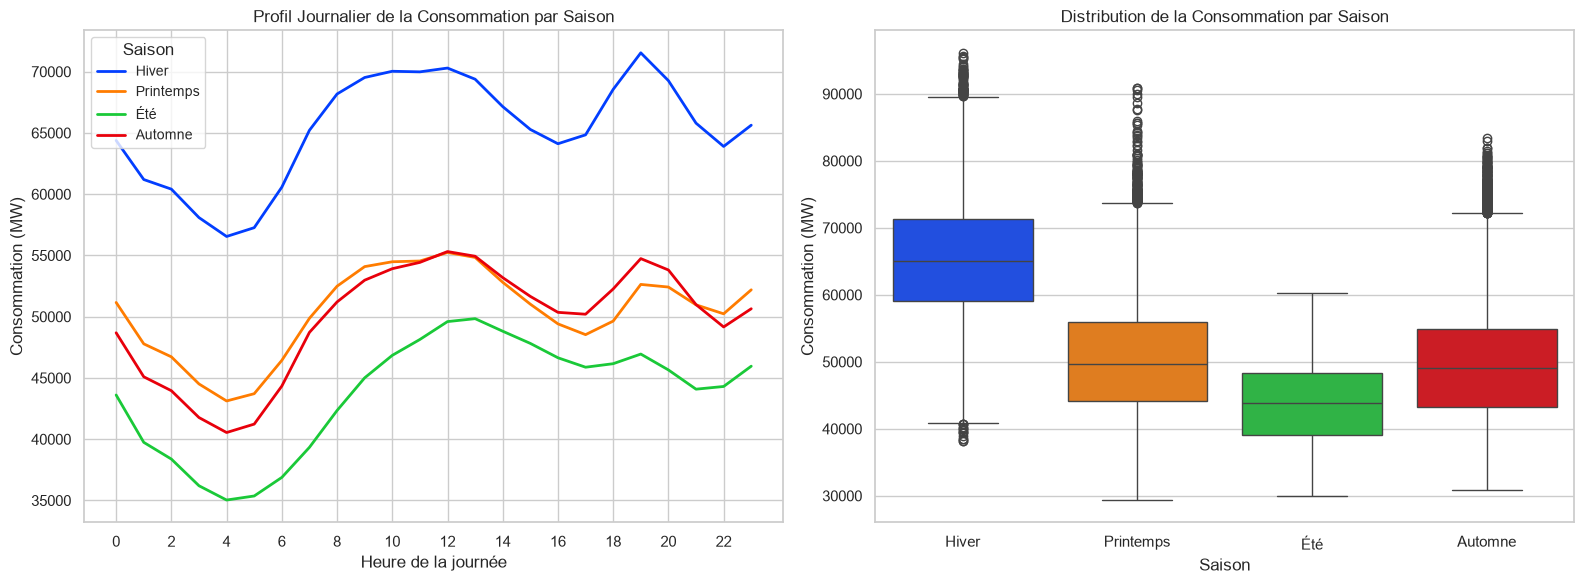

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(
    data=df,
    x='heure',
    y='consommation_mw',
    hue='saison',
    ax=axes[0],
    palette="bright",
    errorbar=None,
    linewidth=2
)

axes[0].set_title("Profil Journalier de la Consommation par Saison")
axes[0].legend(title="Saison", loc='upper left', fontsize='small')
axes[0].set_xlabel("Heure de la journée")
axes[0].set_ylabel("Consommation (MW)")
axes[0].set_xticks(range(0, 24, 2))

sns.boxplot(
    data=df,
    x='saison',
    y='consommation_mw',
    ax=axes[1],
    hue='saison',
    palette="bright",
    legend=False
)

axes[1].set_title("Distribution de la Consommation par Saison")
axes[1].set_xlabel("Saison")
axes[1].set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()

Il y a une différence dans le niveau et l'écart entre des saisons (sauf printemps et automne), ce qui justifie la variable saison.

### 1.2 Cycle Mensuel

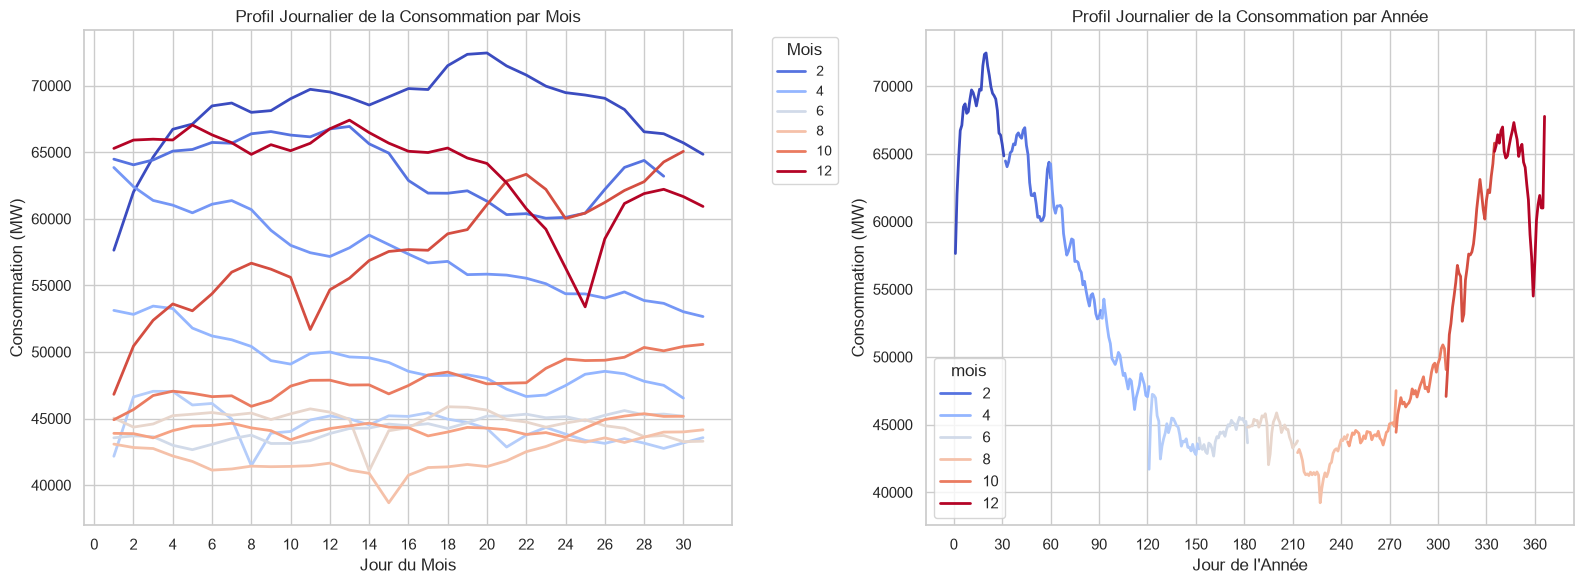

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df['jour_mois'] = df['timestamp_paris'].dt.day

sns.lineplot(data=df, x='jour_mois', y='consommation_mw', hue='mois', ax=axes[0], palette="coolwarm", errorbar=None, linewidth=2)
axes[0].set_title("Profil Journalier de la Consommation par Mois")
axes[0].set_xlabel("Jour du Mois")
axes[0].set_xticks(range(0, 32, 2))
axes[0].set_ylabel("Consommation (MW)")
axes[0].legend(title="Mois", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')


sns.lineplot(data=df, x='jour_annee', y='consommation_mw', hue='mois', ax=axes[1], palette="coolwarm", errorbar=None, linewidth=2)
axes[1].set_title("Profil Journalier de la Consommation par Année")
axes[1].set_xlabel("Jour de l'Année")
axes[1].set_xticks(range(0, 366, 30))
axes[1].set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()

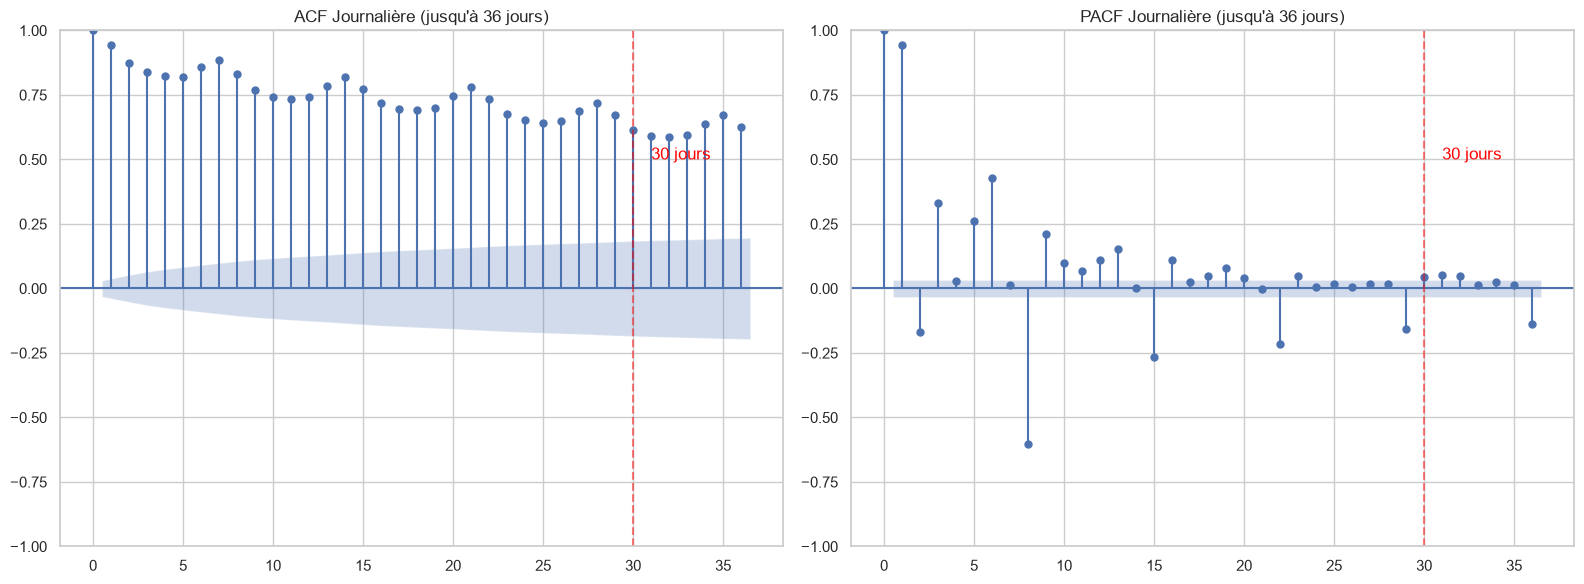

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_acf(df_daily['consommation_mw'], lags=36, ax=axes[0], title="ACF Journalière (jusqu'à 36 jours)")
plot_pacf(df_daily['consommation_mw'], lags=36, ax=axes[1], title="PACF Journalière (jusqu'à 36 jours)")

axes[0].axvline(x=30, color='red', linestyle='--', alpha=0.5)
axes[0].text(31, 0.5, '30 jours', color='red')

axes[1].axvline(x=30, color='red', linestyle='--', alpha=0.5)
axes[1].text(31, 0.5, '30 jours', color='red')

plt.tight_layout()
plt.show()

Mensuelle :
- Il y a pas de tendance, cycle, ou saisonalité mensuelle.
- Il y a une persistence mais à cause des saisonnalités journalières.
- Il y a des trous qui correspondent à des vacances.

### 1.3 Cycle Hebdomadaire

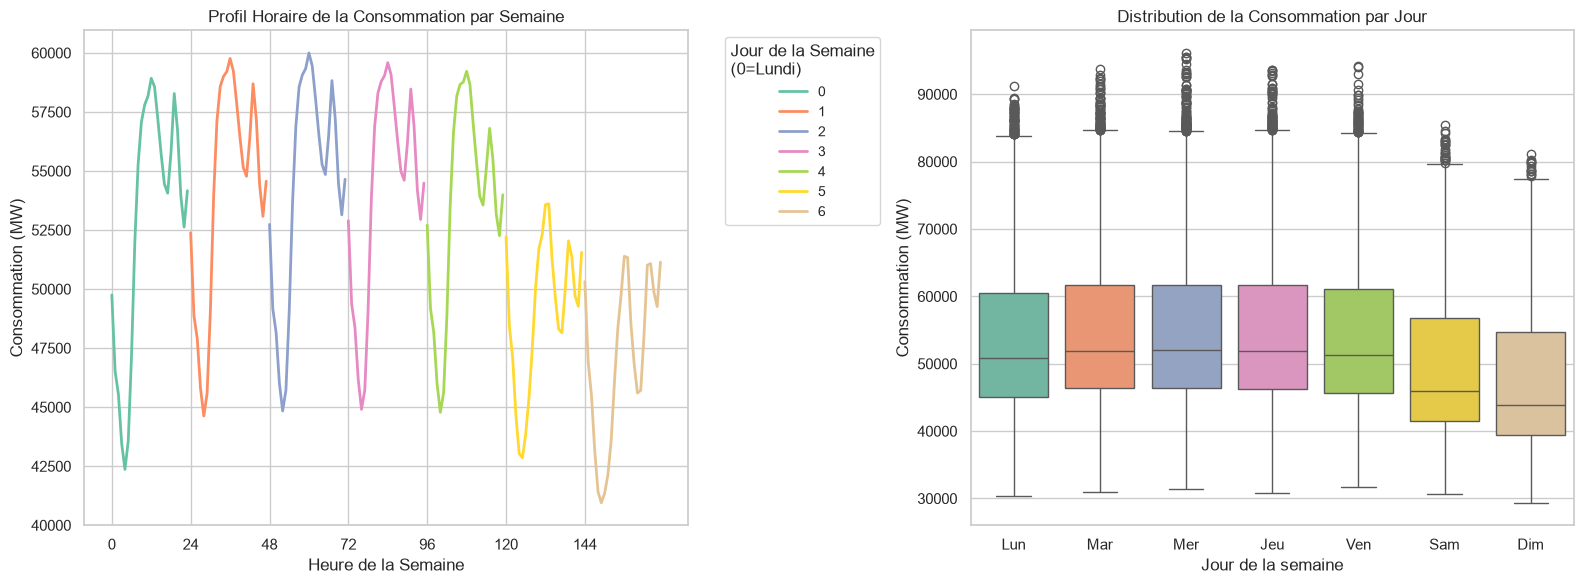

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df['heure_semaine'] = df['timestamp_paris'].dt.hour + df['timestamp_paris'].dt.weekday * 24

sns.lineplot(
	data=df, x='heure_semaine', y='consommation_mw', hue='jour_semaine', ax=axes[0], palette="Set2", errorbar=None, linewidth=2
)
axes[0].set_title("Profil Horaire de la Consommation par Semaine")
axes[0].set_xlabel("Heure de la Semaine")
axes[0].set_xticks(range(0, 168, 24))
axes[0].set_ylabel("Consommation (MW)")
axes[0].legend(title="Jour de la Semaine\n(0=Lundi)", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

sns.boxplot(data=df, x='jour_semaine', y='consommation_mw', ax=axes[1], hue='jour_semaine', palette="Set2", legend=False)
axes[1].set_title("Distribution de la Consommation par Jour")
axes[1].set_xlabel("Jour de la semaine")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(JOURS_SEMAINE)
axes[1].set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()

Le cycle hebdomadaire a trois niveaux : un plateau en semaine, un samedi plus bas et un dimanche encore plus bas.

Carte jour × heure :
- Les jours ouvrés, surtout mardi à jeudi, sont les plus clairs : une montée entre 6 h et 9 h, un plateau de 10 h à 13 h, un léger creux vers 16 h-17 h, puis la pointe de 19 h.
- Le dimanche est la ligne la plus foncée, avec le minimum de la semaine entre 3 h et 6 h.
- Le samedi n'a pas de montée franche le matin, et la pointe du soir est plus discrète.

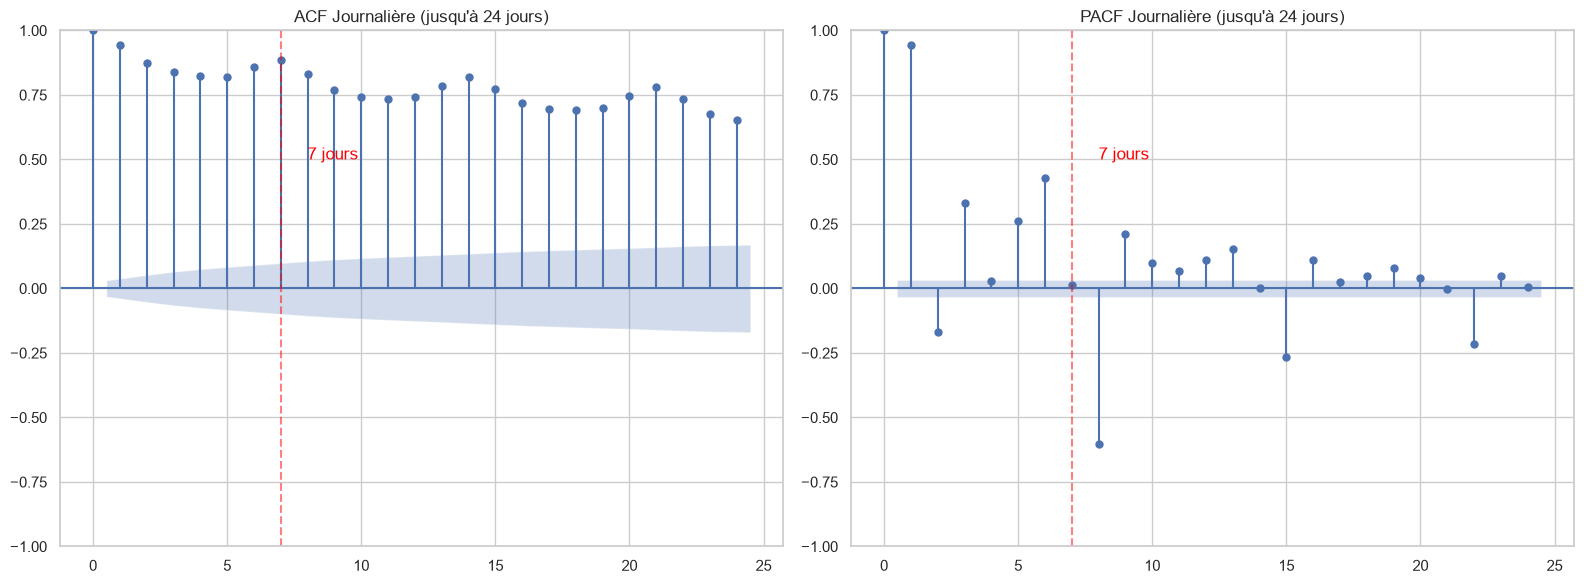

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_acf(df_daily['consommation_mw'], lags=24, ax=axes[0], title="ACF Journalière (jusqu'à 24 jours)")
plot_pacf(df_daily['consommation_mw'], lags=24, ax=axes[1], title="PACF Journalière (jusqu'à 24 jours)")

axes[0].axvline(x=7, color='red', linestyle='--', alpha=0.5)
axes[0].text(8, 0.5, '7 jours', color='red')

axes[1].axvline(x=7, color='red', linestyle='--', alpha=0.5)
axes[1].text(8, 0.5, '7 jours', color='red')

plt.tight_layout()
plt.show()

Hebdomadaire :
- Il y une saisonnalité hebdomadaire.

### 1.4 Cycle Journalier

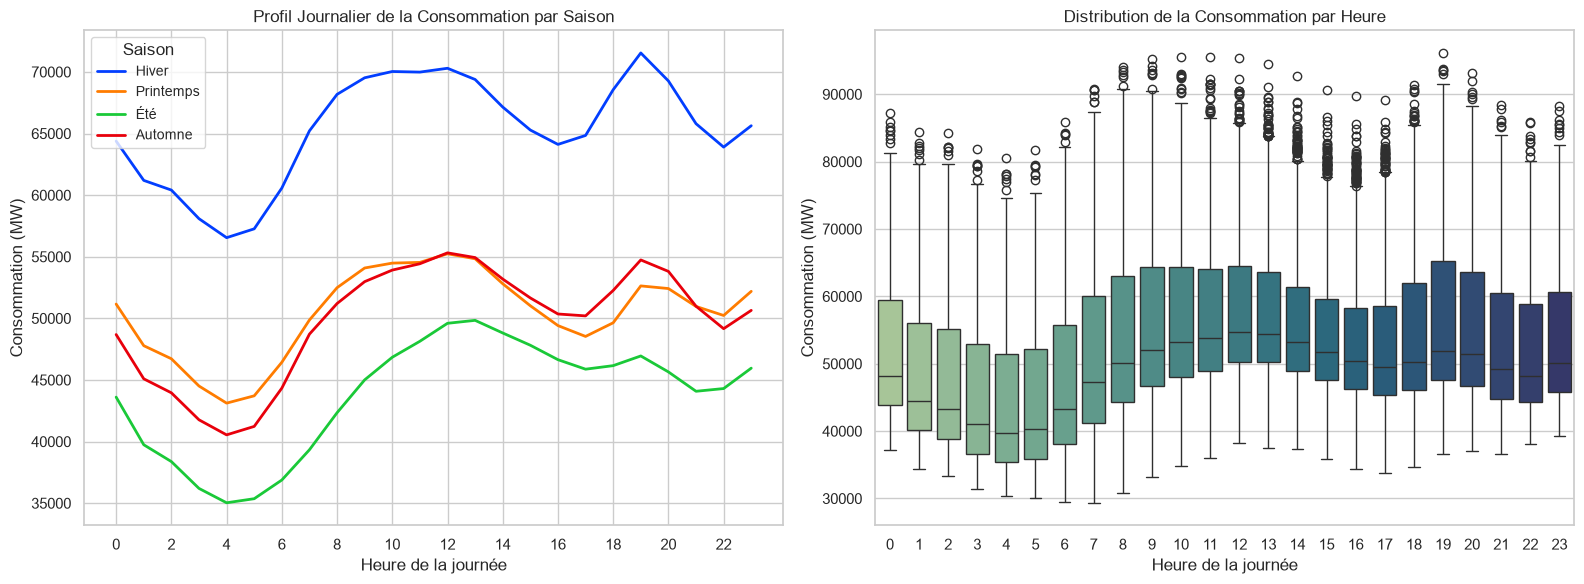

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(data=df, x='heure', y='consommation_mw', hue='saison', ax=axes[0], palette="bright", errorbar=None, linewidth=2)
axes[0].set_title("Profil Journalier de la Consommation par Saison")
axes[0].legend(title="Saison", loc='upper left', fontsize='small')
axes[0].set_xlabel("Heure de la journée")
axes[0].set_ylabel("Consommation (MW)")
axes[0].set_xticks(range(0, 24, 2))

sns.boxplot(data=df, x='heure', y='consommation_mw', ax=axes[1], hue='heure', palette="crest", legend=False)
axes[1].set_title("Distribution de la Consommation par Heure")
axes[1].set_xlabel("Heure de la journée")
axes[1].set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()

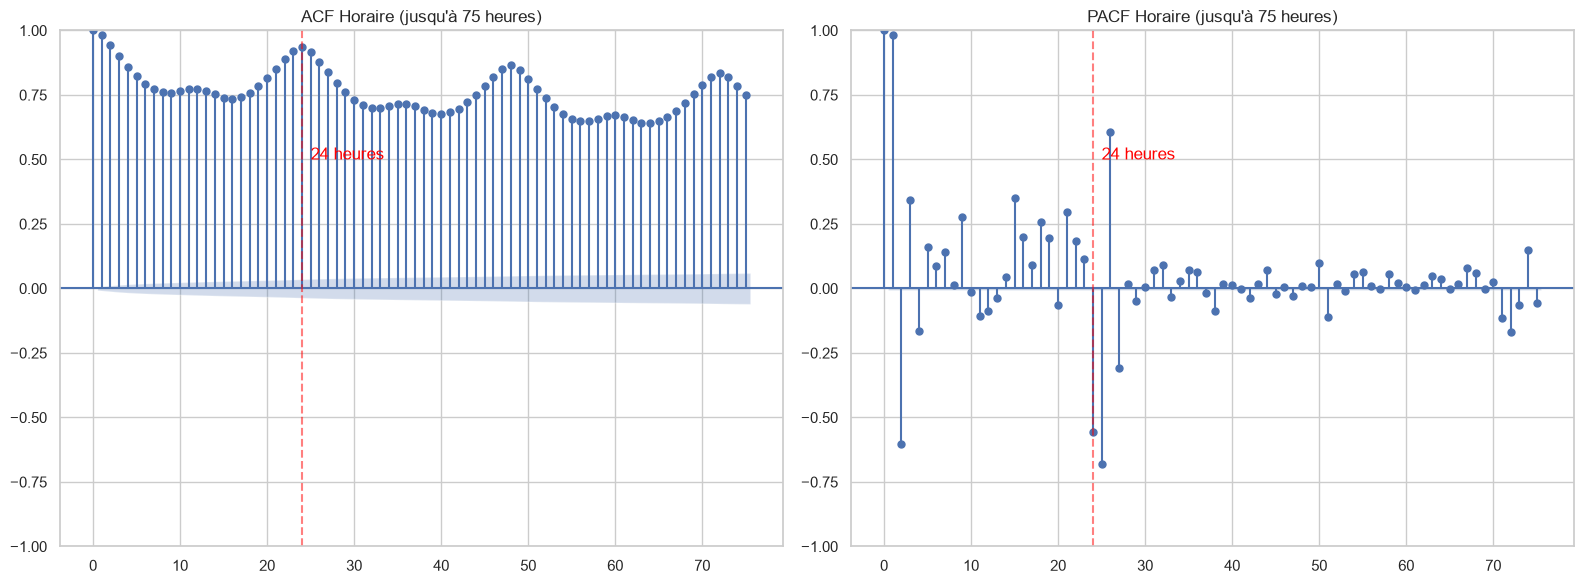

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_acf(df['consommation_mw'], lags=75, ax=axes[0], title="ACF Horaire (jusqu'à 75 heures)")
plot_pacf(df['consommation_mw'], lags=75, ax=axes[1], title="PACF Horaire (jusqu'à 75 heures)")

axes[0].axvline(x=24, color='red', linestyle='--', alpha=0.5)
axes[0].text(25, 0.5, '24 heures', color='red')

axes[1].axvline(x=24, color='red', linestyle='--', alpha=0.5)
axes[1].text(25, 0.5, '24 heures', color='red')

plt.tight_layout()
plt.show()

Journalière :
- Il y a pas de tendance ou cycle journalière.
- Il y a une saisonalité journalière.
- Il y a une persistence.

## 2. Relation avec la Météo

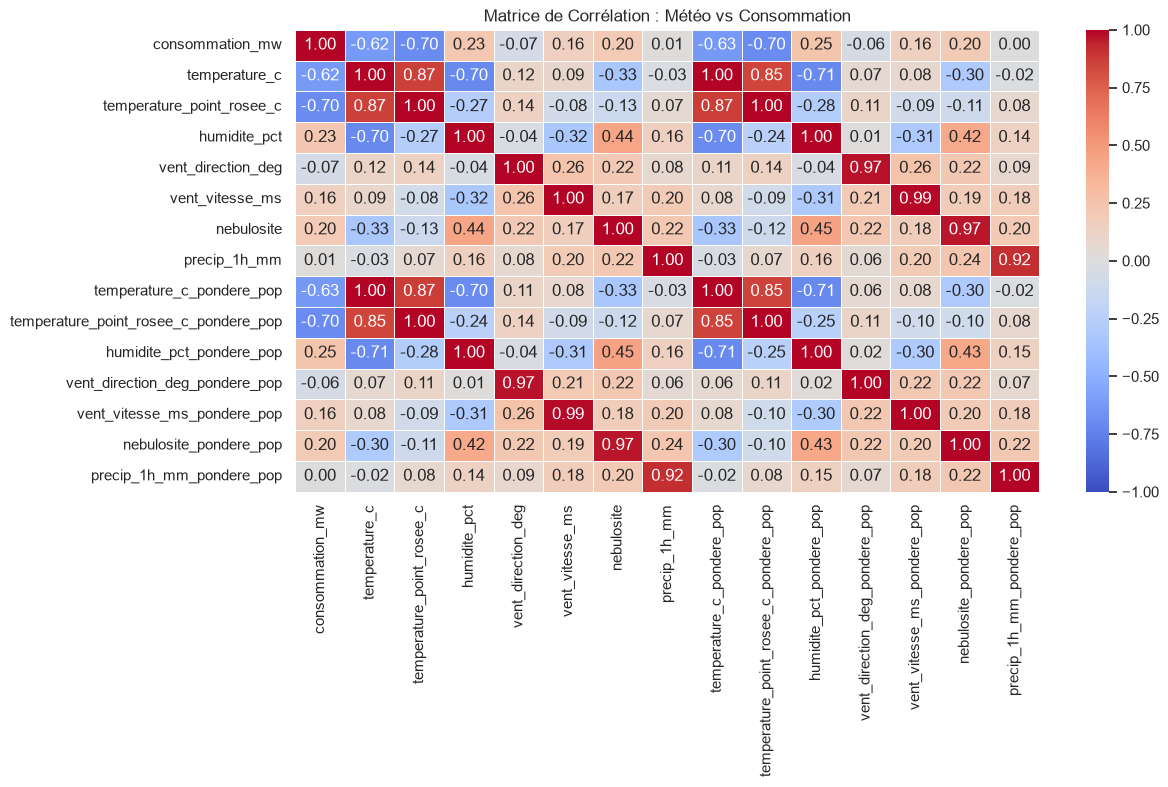

In [24]:
cols_meteo = [
    c for c in df.columns
    if ('temperature' in c or 'humidite' in c or 'vent' in c or 'nebulosite' in c or 'precip' in c)
]

cols_corr = ['consommation_mw'] + cols_meteo
corr_matrix = df[cols_corr].corr()

plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title("Matrice de Corrélation : Météo vs Consommation")
plt.show()

- `temperature_c_pondere_pop` et `temperature_point_rosee_c_pondere_pop` sont bons.
- Mais ils sont très corrélés donc on enlève `temperature_c_pondere_pop` et `humidite` aussi.
- Mais il faut tester aussi les autres (sauf `vent_direction`).

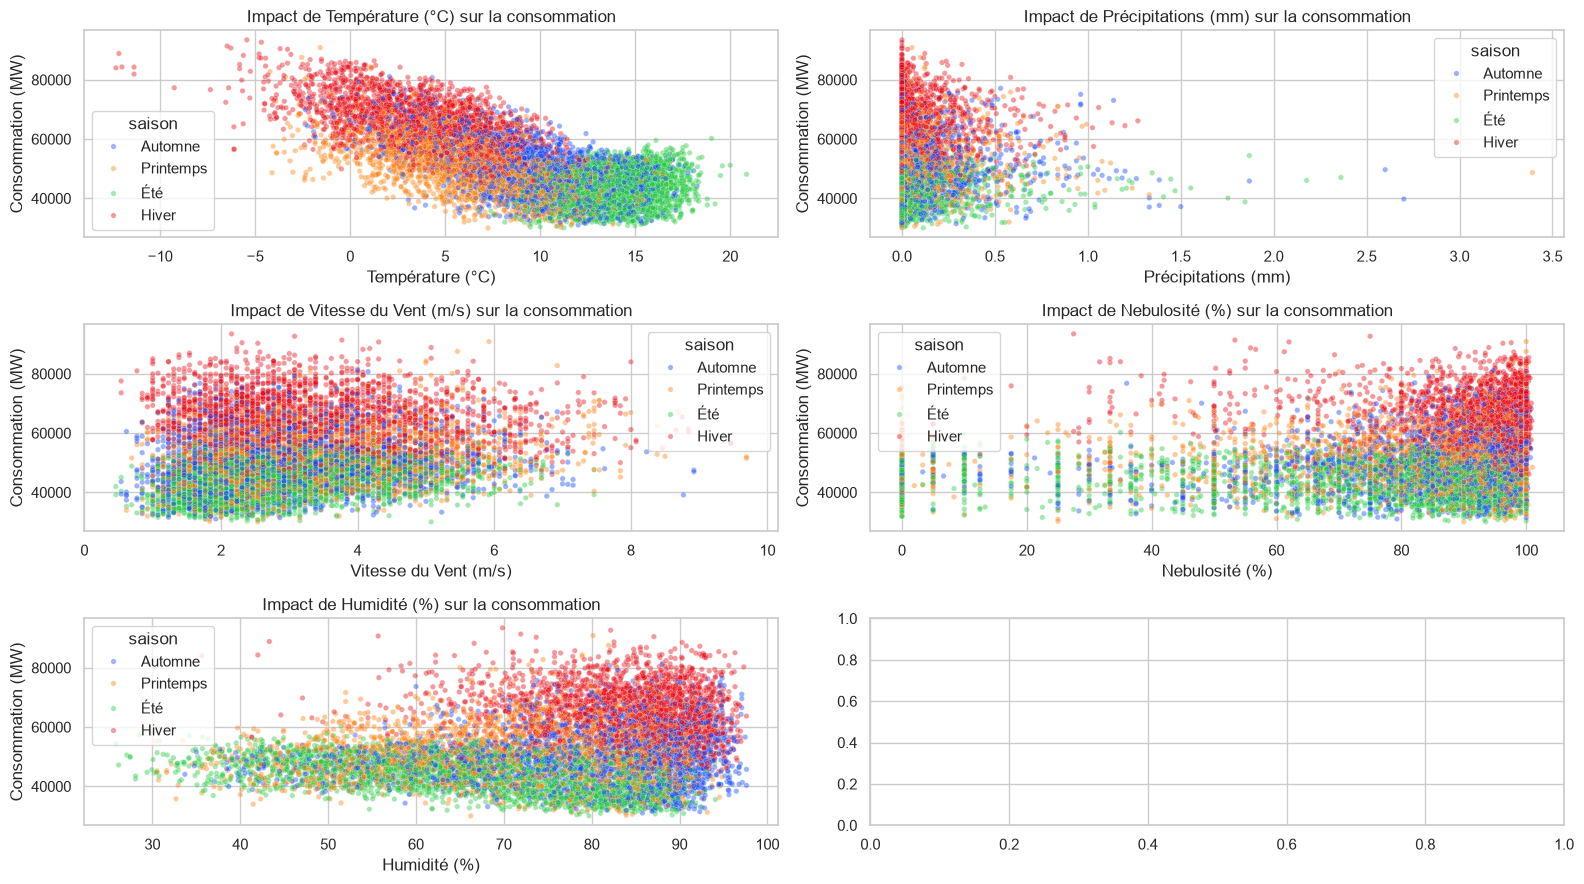

In [28]:
fig, axes = plt.subplots(3, 2, figsize=(16, 9))

variables = [
	("temperature_point_rosee_c", "Température (°C)"),
    ("precip_1h_mm", "Précipitations (mm)"),
    ("vent_vitesse_ms", "Vitesse du Vent (m/s)"),
    ("nebulosite", "Nebulosité (%)"),
    ("humidite_pct", "Humidité (%)"),
]

for ax, (column, label) in zip(axes.flat, variables):
    sns.scatterplot(
        data=df.sample(frac=0.1, random_state=42),
        x=column,
        y="consommation_mw",
        hue="saison",
        alpha=0.4,
        s=15,
        palette="bright",
        ax=ax
    )

    ax.set_title(f"Impact de {label} sur la consommation")
    ax.set_xlabel(label)
    ax.set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()

Température :
- Une relation en U, très nette. La température seule explique environ 81 % de la variance de la consommation journalière. La consommation baisse quand la température monte jusqu'à environ 22 °C, puis remonte légèrement.
- Une forme par morceaux (une pente en dessous d'un seuil, une autre au-dessus) collerait mieux pour les modèles. On le testera dans les modèles avec des variables du type « degrés sous 15 °C » et « degrés au-dessus de 22 °C ».

## 3. Effets Calendaires (Fériés & Vacances)

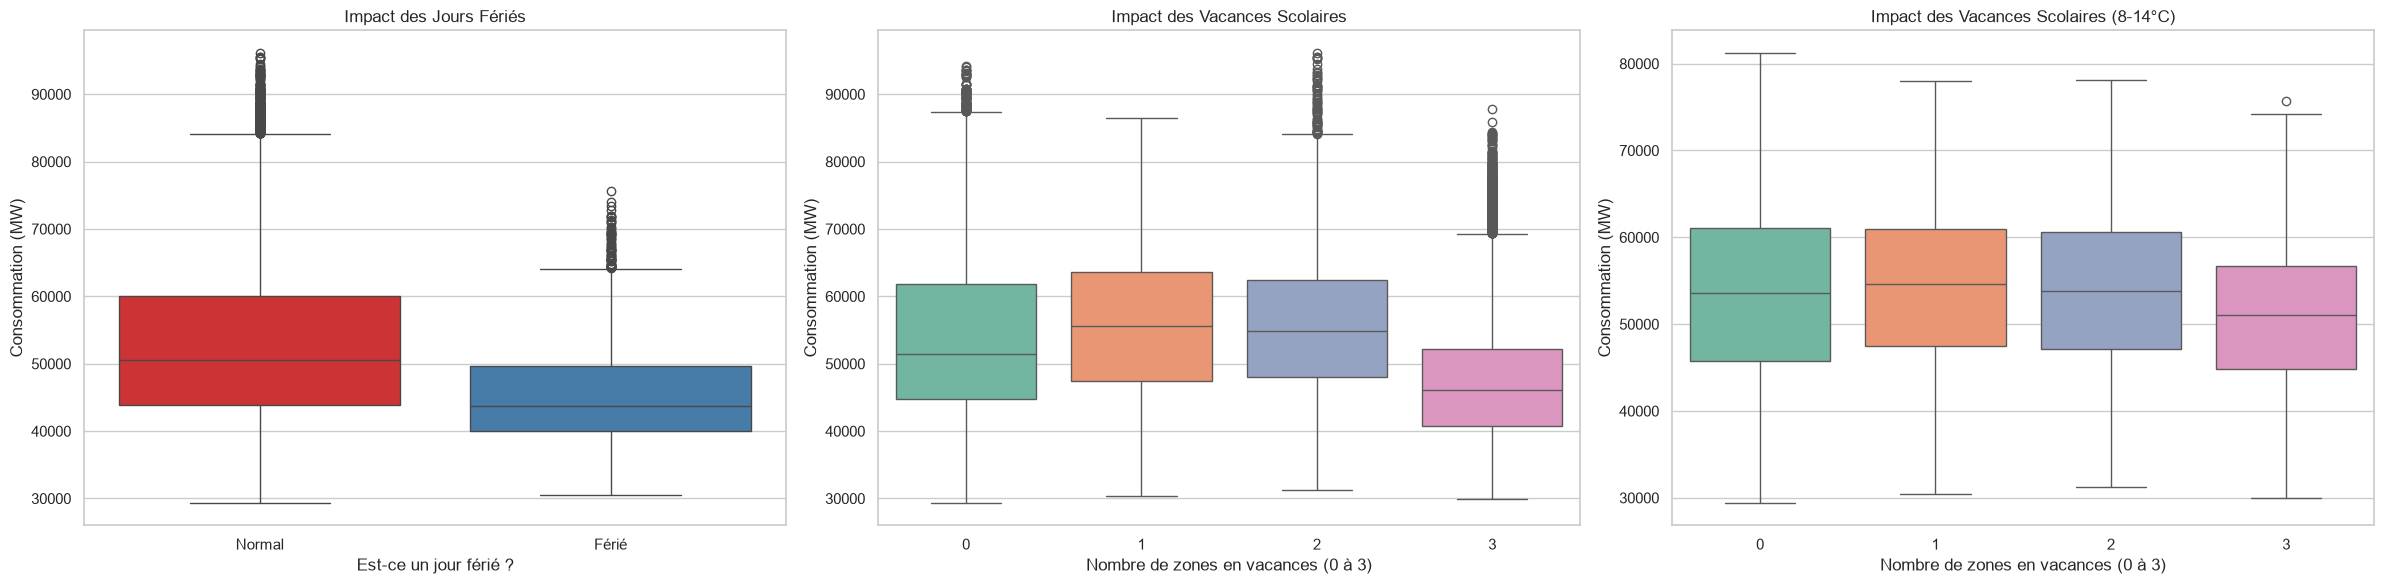

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

sns.boxplot(data=df, x='ferie', y='consommation_mw', ax=axes[0], hue='ferie', palette="Set1", legend=False)
axes[0].set_title("Impact des Jours Fériés")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Normal', 'Férié'])
axes[0].set_xlabel("Est-ce un jour férié ?")
axes[0].set_ylabel("Consommation (MW)")

sns.boxplot(data=df, x='vacances', y='consommation_mw', ax=axes[1], hue='vacances', palette="Set2", legend=False)
axes[1].set_title("Impact des Vacances Scolaires")
axes[1].set_xlabel("Nombre de zones en vacances (0 à 3)")
axes[1].set_ylabel("Consommation (MW)")

df_between_8_14 = df[(df["temperature_c_pondere_pop"] >= 8) & (df["temperature_c_pondere_pop"] < 14)]
sns.boxplot(data=df_between_8_14, x='vacances', y='consommation_mw', ax=axes[2], hue='vacances', palette="Set2", legend=False)
axes[2].set_title("Impact des Vacances Scolaires (8-14°C)")
axes[2].set_xlabel("Nombre de zones en vacances (0 à 3)")
axes[2].set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()

Il y a vrai éffet sur la consommation due à le changement de la rhyme de travail.

## 4. Impact de la COVID

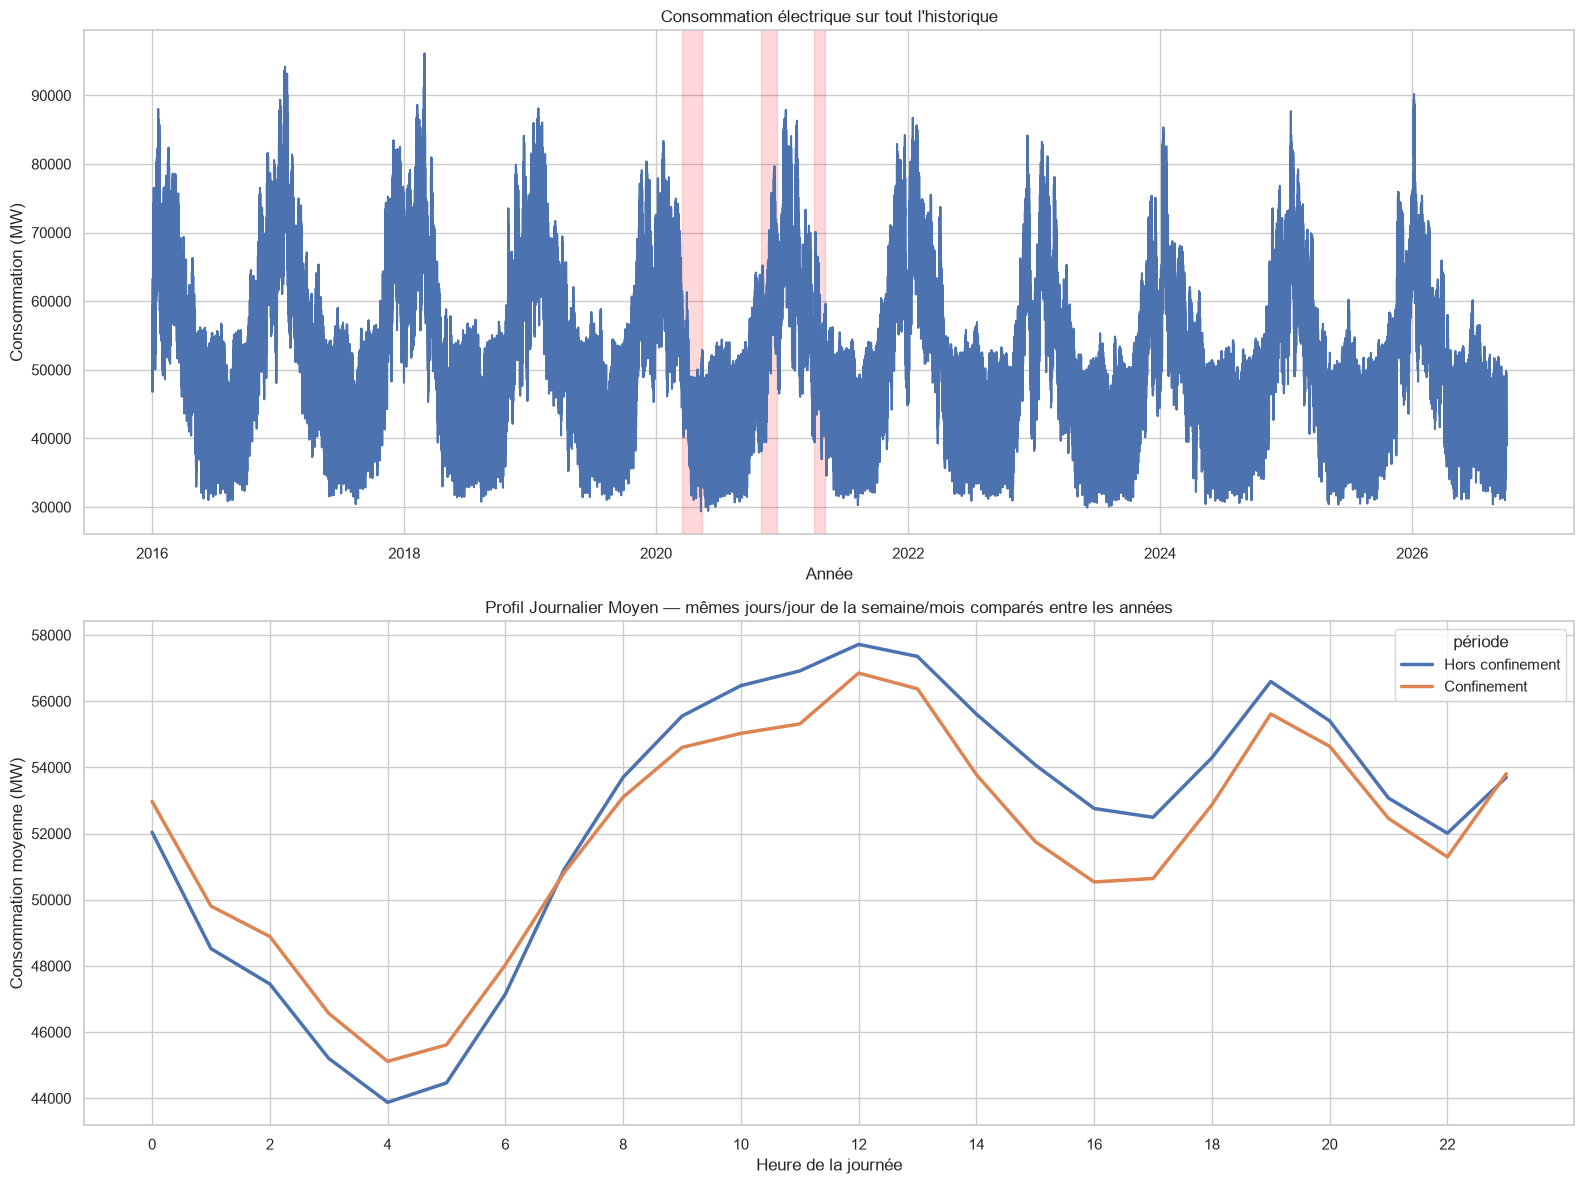

In [ ]:
df_compare = df.copy()

df_compare["est_confinement"] = (df_compare["confinement_numero"] > 0).astype(int)

df_compare["période"] = np.where(
    df_compare["est_confinement"] == 1,
    "Confinement",
    "Hors confinement"
)

comparison = (
    df_compare
        .groupby(["mois", "jour_semaine", "heure", "est_confinement", "période"])["consommation_mw"]
        .mean()
        .reset_index()
)

hourly_comparison = (
    comparison
        .groupby(["heure", "est_confinement", "période"])["consommation_mw"]
        .mean()
        .reset_index()
)

periodes_confinement = (
    df[df["confinement_numero"] > 0]
    .groupby("confinement_numero")["timestamp_paris"]
    .agg(["min", "max"])
)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

sns.lineplot(data=df, x="timestamp_paris", y="consommation_mw", ax=axes[0])

for confinement, periode in periodes_confinement.iterrows():
    debut = periode["min"].tz_localize(None)
    fin = periode["max"].tz_localize(None)

    axes[0].axvspan(debut, fin, color="red", alpha=0.15)


axes[0].set_title("Consommation électrique sur tout l'historique")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Consommation (MW)")

sns.lineplot(
    data=hourly_comparison, x="heure", y="consommation_mw", hue="période",
    hue_order=["Hors confinement", "Confinement"], ax=axes[1], linewidth=2.5
)

axes[1].set_title("Profil Journalier Moyen — mêmes jours/jour de la semaine/mois comparés entre les années")
axes[1].set_xlabel("Heure de la journée")
axes[1].set_ylabel("Consommation moyenne (MW)")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

### Ruptures et observations atypiques

           jour  écart    z  ferie  confinement
date                                           
2022-12-11  Dim  0.360  6.9  False          NaN
2022-12-17  Sam  0.353  6.7  False          NaN
2025-11-22  Sam  0.350  6.7  False          NaN
2024-01-20  Sam  0.344  6.6  False          NaN
2023-01-22  Dim  0.343  6.5  False          NaN
2022-12-18  Dim  0.337  6.4  False          NaN
2022-12-12  Lun  0.329  6.3  False          NaN
2023-01-01  Dim -0.311 -5.9   True          NaN
2024-01-10  Mer  0.309  5.9  False          NaN
2021-02-13  Sam  0.307  5.8  False          NaN
2022-12-10  Sam  0.302  5.8  False          NaN
2025-11-23  Dim  0.299  5.7  False          NaN
2024-01-11  Jeu  0.298  5.7  False          NaN
2025-11-21  Ven  0.298  5.7  False          NaN
2026-01-06  Mar  0.292  5.6  False          NaN
2024-01-12  Ven  0.292  5.6  False          NaN
2026-01-07  Mer  0.289  5.5  False          NaN
2024-01-19  Ven  0.289  5.5  False          NaN
2024-01-13  Sam  0.288  5.5  False      

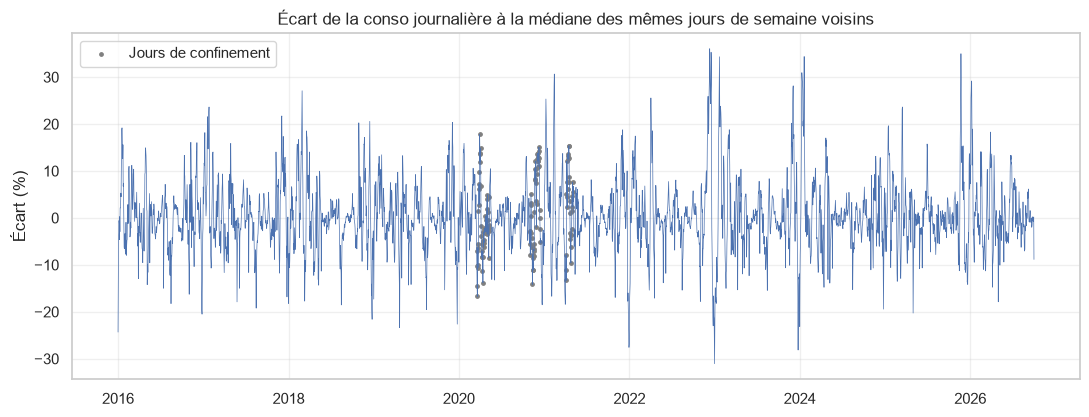

In [ ]:
# Écart de chaque jour à la médiane des mêmes jours de semaine voisins (±4 semaines)
# asfreq("D") remet les jours absents (NaN) pour que les décalages de 7 jours tombent bien sur le même jour de semaine
daily = df.groupby("date").agg(
    conso_moy=("consommation_mw", "mean"),
    conso_max=("consommation_mw", "max"),
    n_heures=("consommation_mw", "count"),
    temp=("temperature_c", "mean"),
    temp_pop=("temperature_c_pondere_pop", "mean"),
    jour_semaine=("jour_semaine", "first"),
    ferie=("ferie", "first"),
    saison=("saison", "first"),
    mois=("mois", "first"),
    annee=("annee", "first"),
    confinement=("confinement_numero", "max"),
    vacances=("vacances", "first")
)

s = daily["conso_moy"].asfreq("D")
ref = pd.concat([s.shift(7 * k) for k in (-4, -3, -2, -1, 1, 2, 3, 4)], axis=1).median(axis=1)
resid = (s / ref - 1).dropna()
z = (resid - resid.median()) / (1.4826 * (resid - resid.median()).abs().median())

top = z.abs().sort_values(ascending=False).head(20).index
atypiques = pd.DataFrame({
    "jour": daily.loc[top, "jour_semaine"].map(dict(enumerate(JOURS_SEMAINE))),
    "écart": resid[top].round(3),
    "z": z[top].round(1),
    "ferie": daily.loc[top, "ferie"],
    "confinement": daily.loc[top, "confinement"]})
print(atypiques)

plt.figure(figsize=(13, 4.5))
plt.plot(resid.index, resid * 100, lw=.5)
covid_idx = resid.index[daily.loc[resid.index, "confinement"].notna().values]
plt.scatter(covid_idx, resid[covid_idx] * 100, s=6, color="grey", label="Jours de confinement")
plt.ylabel("Écart (%)")
plt.title("Écart de la conso journalière à la médiane des mêmes jours de semaine voisins")
plt.legend()
plt.grid(alpha=.3)
plt.show()

In [ ]:
# Maximum horaire de chaque année
pics = df.loc[df.groupby("annee")["consommation_mw"].idxmax(), ["timestamp_paris", "consommation_mw"]]
print(pics.to_string(index=False))

          timestamp_paris  consommation_mw
2016-01-18 19:00:00+01:00          88025.5
2017-01-20 09:00:00+01:00          94186.5
2018-02-28 19:00:00+01:00          96129.5
2019-01-24 19:00:00+01:00          88106.0
2020-01-22 09:00:00+01:00          83358.0
2021-01-11 19:00:00+01:00          87864.5
2022-01-14 09:00:00+01:00          86744.0
2023-01-23 19:00:00+01:00          83250.0
2024-01-10 19:00:00+01:00          85342.0
2025-01-14 09:00:00+01:00          87702.5
2026-01-06 10:00:00+01:00          90209.5


- Jours atypiques  : les plus extrêmes sont tous en hiver, presque tous des surconsommations de +29 à +36 % lors de coups de froid brusques, en 6 épisodes : décembre 2022, janvier 2023, janvier 2024, novembre 2025, janvier 2026 et le 13 février 2021. Le seul écart négatif est le 1er janvier 2023 (dimanche férié, −31 %). 12 jours sur 20 tombent un week-end (niveau de base plus bas donc pourcentage plus grand). 

- Pics annuels de consommation horaire : toujours en hiver. Le niveau dépend de la vague de froid. Le modèle devra bien prévoir les deux pics de la journée 

- Effet des confinements (comparaison aux mêmes dates des années voisines sans confinement, météo non contrôlée) : −16,8 % pour le premier, −6,8 % pour le deuxième, +4,3 % pour le troisième. Seul le premier est net ; les deux autres restent dans le bruit de la météo, donc, pas trop de soucie de l'inclure.

- Jours atypiques retenus :
	- parce qu'il peut être expliqué par la temperature.
	- pour l'analyse des échecs : 2022-12-11 (coup de froid brusque), 2023-01-01 (férié d'hiver), 2018-02-28 (pic record), un jour du premier confinement (par exemple 2020-03-17).

### Changement d'heure

Jours avec deux occurrences de 2h :
[datetime.date(2016, 10, 30), datetime.date(2017, 10, 29), datetime.date(2018, 10, 28), datetime.date(2019, 10, 27), datetime.date(2020, 10, 25), datetime.date(2021, 10, 31), datetime.date(2022, 10, 30), datetime.date(2023, 10, 29), datetime.date(2024, 10, 27), datetime.date(2025, 10, 26)]


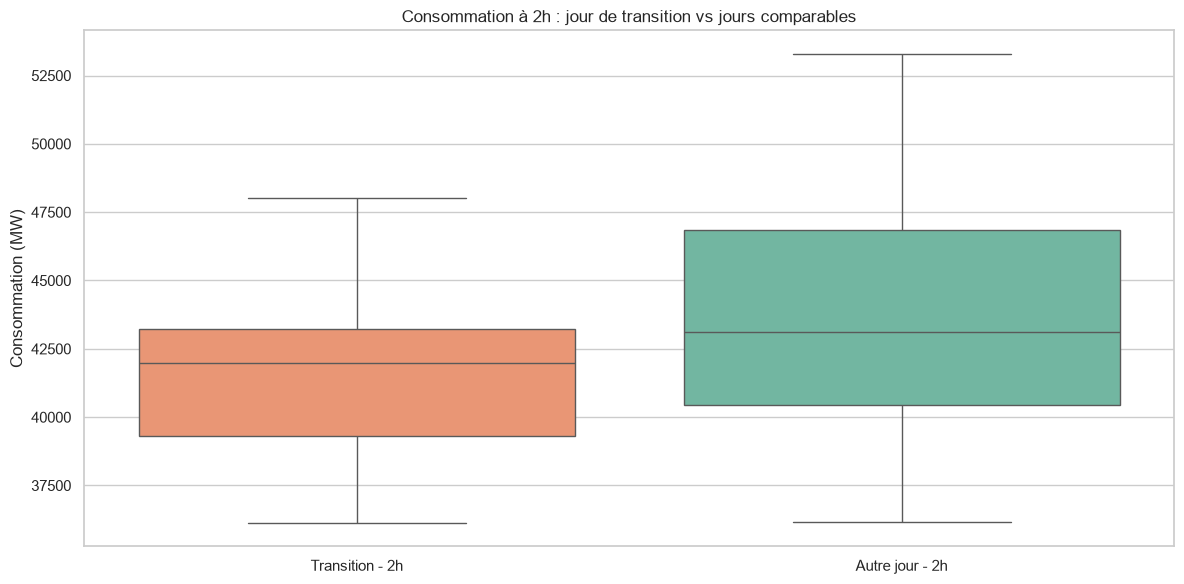


Moyennes :
type_jour
Autre jour    43818.775
Transition    41777.050
Name: consommation_mw, dtype: float64

Écart relatif : -4.66 %


In [ ]:
# Présence de 2h pour chaque jour
presence_2h = (
    df[df["heure"] == 2]
    .groupby(df["timestamp_paris"].dt.date)["timestamp_paris"]
    .apply(list)
)

# Jours où 2h apparaît deux fois
jours_2h_double = sorted(
    date
    for date, timestamps in presence_2h.items()
    if len(timestamps) == 2
)

tz = df["timestamp_paris"].dt.tz
comparaisons = []

for date_transition in jours_2h_double:

    transition = pd.Timestamp(date_transition).tz_localize(tz)

    # Même jour de la semaine
    jour_semaine = transition.dayofweek

    # Une semaine avant et une semaine après
    debut = transition - pd.DateOffset(weeks=1)
    fin = transition + pd.DateOffset(weeks=1)

    periode = df[
        (df["timestamp_paris"].dt.date >= debut.date()) &
        (df["timestamp_paris"].dt.date <= fin.date()) &
        (df["heure"] == 2) &
        (df["timestamp_paris"].dt.dayofweek == jour_semaine)
    ].copy()

    # Offset UTC de chaque observation
    periode["offset_utc"] = periode["timestamp_paris"].apply(
        lambda x: x.utcoffset().total_seconds() / 3600
    )

    # Identifier le jour de transition
    periode["jour_transition"] = (
        periode["timestamp_paris"].dt.date == date_transition
    )

    periode["date_transition"] = date_transition

    # Pour le jour de transition :
    # garder uniquement la vraie 2h UTC+1.
    # La 2h UTC+2 interpolée est supprimée.
    periode = periode[
        (~periode["jour_transition"]) |
        (periode["offset_utc"] == 1)
    ]

    comparaisons.append(periode)


comparaison_2h = pd.concat(
    comparaisons,
    ignore_index=True
)


# Identifier les jours comparables
comparaison_2h["type_jour"] = np.where(
    comparaison_2h["jour_transition"],
    "Transition",
    "Autre jour"
)


# Catégories
comparaison_2h["categorie"] = (
    comparaison_2h["type_jour"] + " - 2h"
)

ordre = [
    "Transition - 2h",
    "Autre jour - 2h"
]


plt.figure(figsize=(16, 6))

sns.boxplot(
    data=comparaison_2h,
    x="categorie",
    y="consommation_mw",
    hue="categorie",
    order=ordre,
    palette="Set2",
    legend=False
)

plt.title("Consommation à 2h : jour de transition vs jours comparables")
plt.xlabel("")
plt.ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()


moyennes_2h = (
    comparaison_2h
    .groupby(["type_jour"])["consommation_mw"]
    .mean()
)


# Écart relatif : Transition par rapport aux autres jours
ecart_relatif_2h = (
    (moyennes_2h["Transition"] - moyennes_2h["Autre jour"])
    / moyennes_2h["Autre jour"]
    * 100
)


print("\nMoyennes :")
print(moyennes_2h)

print(f"\nÉcart relatif : {ecart_relatif_2h:.2f} %")

On compare 2h le jour de transition avec 2h les même jour de la semaines du semaine avant et après.

On peut voir qu'il y a une difference de moins de 5%, et il y a que 10 jours de transition, donc on peut assumer qu'il y a pas de difference dans la consommation selons heure locale sans problème.

[datetime.date(2016, 3, 27), datetime.date(2017, 3, 26), datetime.date(2018, 3, 25), datetime.date(2019, 3, 31), datetime.date(2020, 3, 29), datetime.date(2021, 3, 28), datetime.date(2022, 3, 27), datetime.date(2023, 3, 26), datetime.date(2024, 3, 31), datetime.date(2025, 3, 30), datetime.date(2026, 3, 29)]


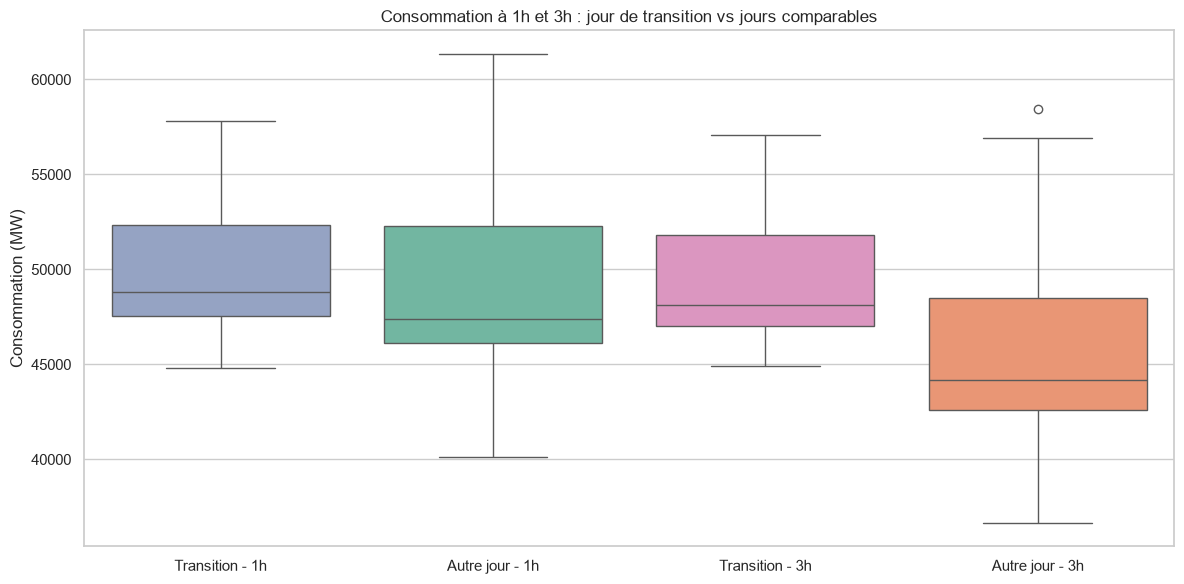

type_jour    Autre jour    Transition  ecart_relatif_%
heure                                                 
1          49844.818182  50203.772727         0.720144
3          46203.727273  49660.772727         7.482179


In [ ]:
# Présence des heures 1h, 2h et 3h pour chaque jour
presence_heures = (
    df[df["heure"].isin([1, 2, 3])]
    .groupby(df["timestamp_paris"].dt.date)["heure"]
    .apply(lambda x: set(x))
)

# Jours où 1h et 3h existent mais 2h est absente
jours_2h_manquante = sorted(
    date
    for date, heures in presence_heures.items()
    if 1 in heures and 3 in heures and 2 not in heures
)

tz = df["timestamp_paris"].dt.tz
comparaisons = []

for date_transition in jours_2h_manquante:
    transition = pd.Timestamp(date_transition).tz_localize(tz)

    # Même jour de la semaine
    jour_semaine = transition.dayofweek

    # 1 semaines avant et 1 semaines après
    debut = transition - pd.DateOffset(weeks=1)
    fin = transition + pd.DateOffset(weeks=1)

    periode = df[
        (df["timestamp_paris"].dt.date >= debut.date()) &
        (df["timestamp_paris"].dt.date <= fin.date()) &
        (df["heure"].isin([1, 3])) &
        (df["timestamp_paris"].dt.dayofweek == jour_semaine)
    ].copy()

    periode["jour_transition"] = (
        periode["timestamp_paris"].dt.date == date_transition
    )

    periode["date_transition"] = date_transition

    comparaisons.append(periode)

comparaison = pd.concat(
    comparaisons,
    ignore_index=True
)

# Identifier les jours comparables
comparaison["type_jour"] = np.where(
    comparaison["jour_transition"],
    "Transition",
    "Autre jour"
)

# Combiner heure + type de jour pour obtenir 4 catégories
comparaison["categorie"] = (
    comparaison["type_jour"]
    + " - "
    + comparaison["heure"].astype(str)
    + "h"
)

# Ordre souhaité
ordre = [
    "Transition - 1h",
    "Autre jour - 1h",
    "Transition - 3h",
    "Autre jour - 3h"
]

plt.figure(figsize=(16, 6))

sns.boxplot(
    data=comparaison,
    x="categorie",
    y="consommation_mw",
    hue="categorie",
    order=ordre,
    palette="Set2",
    legend=False
)

plt.title("Consommation à 1h et 3h : jour de transition vs jours comparables")
plt.xlabel("")
plt.ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()

# Moyenne par catégorie
moyennes = (
    comparaison
    .groupby(["heure", "type_jour"])["consommation_mw"]
    .mean()
    .unstack()
)

# Écart relatif : Transition par rapport aux autres jours
moyennes["ecart_relatif_%"] = (
    (moyennes["Transition"] - moyennes["Autre jour"])
    / moyennes["Autre jour"]
    * 100
)

print(moyennes)

On compare 1h et 3h le jour de transition avec 1h et 3h les même jour de la semaines du semaine avant et après.

On peut voir qu'il y a une difference de moins de 10%, et il y a que 10 jours de transition, donc on peut assumer qu'il y a pas de difference dans la consommation selons heure locale sans problème.

## Conclusion

Cette analyse exploratoire met en évidence une **forte structure temporelle** de la consommation électrique, avec des variations selon l'heure, le jour de la semaine et la période de l'année. Je soupçonne notamment des **saisonnalités journalière, hebdomadaire et annuelle**, cohérentes avec les profils observés. L'**ACF et la PACF** confirment la présence de dépendances temporelles et permettent d'identifier les retards potentiellement pertinents pour la modélisation.

La série présente également une **tendance à long terme**, confirmée par la décomposition STL et par l'évolution de la moyenne et de l'écart-type. On observe notamment des niveaux et écarts différents **avant, pendant et après la période COVID-19**.

Les variations de température et les variables calendaires apparaissent également comme des facteurs importants. Les **changements d'heure** sont interprétés en heure locale de Paris ; l'effet du changement d'heure lui-même ne semble pas constituer une composante à modéliser séparément.

Ces observations orientent naturellement le choix des modèles : les saisonnalités multiples pourront être exploitées par **XGBoost, Prophet ou une régression avec termes de Fourier**, tandis que les effets spécifiques de la période COVID-19, la calandrier ou la météo pourront être intégrés explicitement, notamment dans les modèles comme **XGBoost ou LSTM**. Mais depuis 2022, le niveau et l'écart est très stable, donc, après l'enlevement de la saisonnalité, la série peut-être stationnaire et **SARIMAX** peut marcher parce qu'il ne demande pas beaucoup de données.

Enfin, les observations atypiques ne seront pas supprimées systématiquement : elles peuvent correspondre à des événements réels tels que des conditions météorologiques extrêmes, des jours fériés ou des périodes exceptionnelles.